<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/ProyectoFinal_AlvaroHernandez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto final**
## **Predicción de síntomas médicos**

* Asignatura: Procesamiento del Lenguaje Natural
* Profesor: Dr. Rogelio Florencia Juárez
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* 10 de mayo de 2026




En este proyecto desarrollarán un sistema para la predicción de síntomas médicos a partir de datos textuales recogidos de registros o transcripciones médicas. El objetivo es aplicar técnicas de PLN para preprocesar, representar, modelar y evaluar el texto con foco en aplicaciones de salud.<br>

El dataset contiene ejemplos de diferentes síntomas médicos descritos en formato textual con el objetivo de construir modelos que puedan identificar el síntoma presente en una entrada dada. Cada muestra pertenece a una de varias clases que representan síntomas o condiciones comunes reportadas por pacientes.<br>


**Criterios de evaluación:**
1. Análisis exploratorio (EDA) completo del dataset.
2.	Preprocesamiento y normalización de los textos almacenados en la columna (Phrase). También pon atención a los valores almacenados en la columna (Prompt).
3.	Generación de representaciones vectoriales empleando embeddings contextuales o utilización de embeddings pre-entrenados.
4.	Entrenamiento de tres modelos distintos y optimización, ajustando sus parámetros (puedes utilizar GridSearch).
5.	Validación cruzada estratificada de 10 folds.
6.	Evaluar los modelos con las métricas apropiadas y seleccionar el mejor explicando por qué.
7.	Entregar código reproducible, documentación clara y un reporte técnico con análisis crítico.


**Entregables:**
 * Script de python: código completo documentado.
 *	Reporte técnico en un documento de Word (alrededor de 10 páginas) que incluya: introducción, metodología, resultados, discusiones, conclusiones y trabajo futuro. Incluir tabla(s) de resultados, visualizaciones, etc.


In [ ]:
# Instalación de librerías requeridas
!pip install -q sentence-transformers
!pip install -q spacy
!python -m spacy download en_core_web_sm

# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import spacy

# Carga global del modelo de lenguaje de spaCy (inglés)
nlp = spacy.load("en_core_web_sm")


from sentence_transformers import SentenceTransformer
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 76.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### **Carga y verificación de datos**

In [ ]:
# Carga del conjunto de datos
ruta_archivo = "/content/drive/MyDrive/ClassFiles/Dataset.csv"

# Leer el archivo CSV
df = pd.read_csv(ruta_archivo)

# Visualización preliminar de los datos
print("Primeras filas del dataset:")
display(df.head())

# Información estructural del dataset
print("\nInformación general del dataset:")
df.info()

# Conteo de valores nulos
print("\nConteo de valores nulos por columna:")
print(df.isnull().sum())

Primeras filas del dataset:


,phrase,prompt
0,When I remember her I feel down,Emotional pain
1,When I carry heavy things I feel like breaking...,Hair falling out
2,there is too much pain when i move my arm,Heart hurts
3,My son had his lip pierced and it is swollen a...,Infected wound
4,My muscles in my lower back are aching,Infected wound



Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6661 entries, 0 to 6660
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   phrase  6661 non-null   object
 1   prompt  6661 non-null   object
dtypes: object(2)
memory usage: 104.2+ KB

Conteo de valores nulos por columna:
phrase    0
prompt    0
dtype: int64


### **1. Análisis Exploratorio de Datos (EDA)**

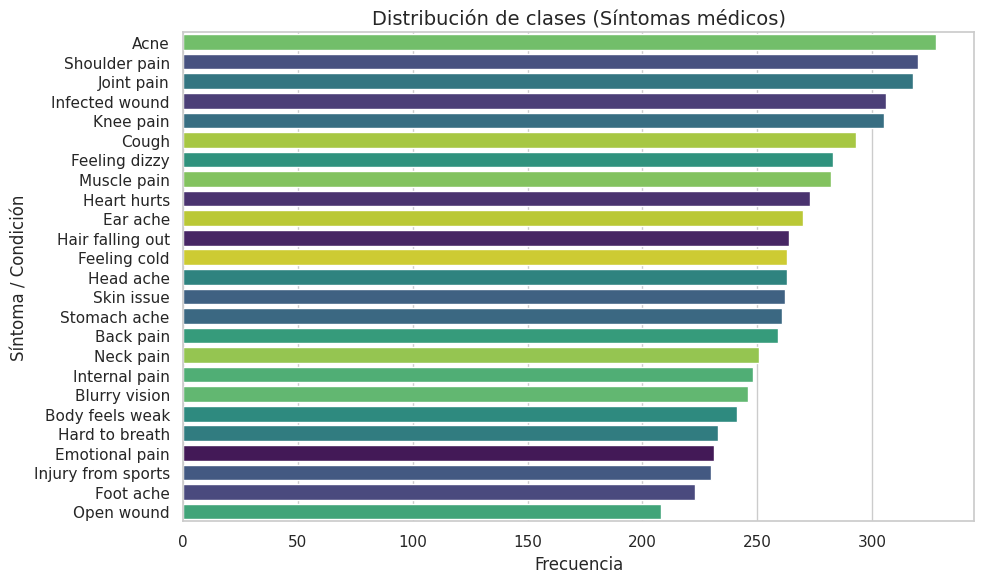


Distribución numérica de clases
                    Frecuencia  Porcentaje (%)
prompt                                        
Acne                       328            4.92
Shoulder pain              320            4.80
Joint pain                 318            4.77
Infected wound             306            4.59
Knee pain                  305            4.58
Cough                      293            4.40
Feeling dizzy              283            4.25
Muscle pain                282            4.23
Heart hurts                273            4.10
Ear ache                   270            4.05
Hair falling out           264            3.96
Feeling cold               263            3.95
Head ache                  263            3.95
Skin issue                 262            3.93
Stomach ache               261            3.92
Back pain                  259            3.89
Neck pain                  251            3.77
Internal pain              248            3.72
Blurry vision              

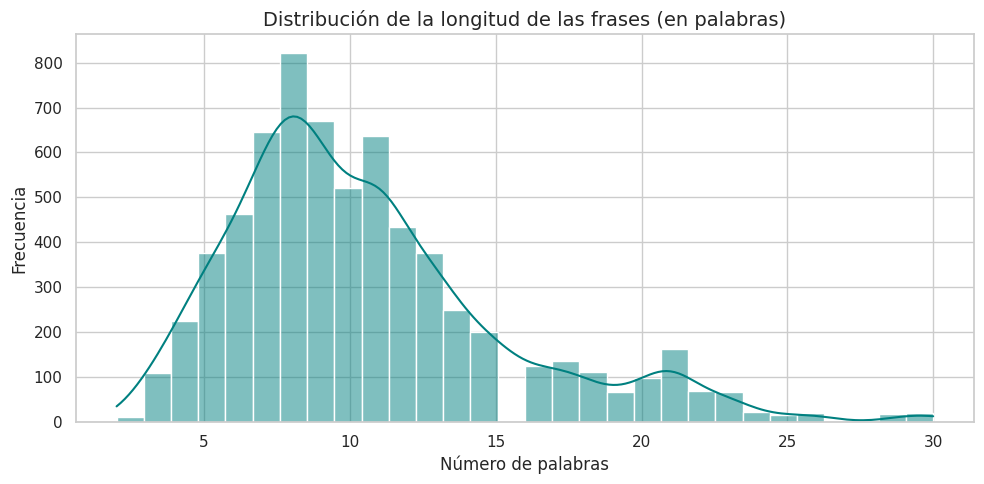


Estadísticas descriptivas de la longitud de los textos:
count    6661.000000
mean       10.543462
std         4.807787
min         2.000000
25%         7.000000
50%        10.000000
75%        13.000000
max        30.000000
Name: phrase_word_count, dtype: float64

⚠️ ADVERTENCIA: 11 frases tienen menos de 3 palabras.
Ejemplos:
                phrase          prompt
13           Don't cry      Joint pain
148   i'm disappointed  Emotional pain
565   i'm disappointed  Emotional pain
3107  i'm disappointed  Emotional pain
3430  i'm disappointed  Emotional pain

Verificación de duplicados exactos
⚠️ Se encontraron 5955 filas duplicadas en la columna 'phrase'.

Ejemplos de frases duplicadas (primeras 5):
                       phrase            prompt
1091  A terrible fall in hair  Hair falling out
5195  A terrible fall in hair  Hair falling out
4143  A terrible fall in hair  Hair falling out
1081  A terrible fall in hair  Hair falling out
1291  A terrible fall in hair  Hair falling out


In [ ]:
# Configuración de estilo
sns.set_theme(style="whitegrid")

# Distribución de clases (Síntomas / Condiciones)
# Gráfico de barras horizontal
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    y='prompt',
    hue='prompt',
    order=df['prompt'].value_counts().index,
    palette='viridis',
    legend=False
    )
plt.title('Distribución de clases (Síntomas médicos)', fontsize=14)
plt.xlabel('Frecuencia')
plt.ylabel('Síntoma / Condición')
plt.tight_layout()
plt.show()

# Tabla numérica con porcentajes
print("\n" + "="*60)
print("Distribución numérica de clases")
print("="*60)
clase_counts = df['prompt'].value_counts()
clase_percent = df['prompt'].value_counts(normalize=True) * 100
distribucion_df = pd.DataFrame({
    'Frecuencia': clase_counts,
    'Porcentaje (%)': clase_percent.round(2)
})
print(distribucion_df)
print(f"\nTotal de muestras: {len(df)}")
print(f"Número de clases únicas: {df['prompt'].nunique()}")

# Detectar clases minoritarias (menos de 30 ejemplos)
clases_minoritarias = clase_counts[clase_counts < 30]
if len(clases_minoritarias) > 0:
    print("\n⚠️ ATENCIÓN: Clases con menos de 30 muestras (pueden afectar la validación cruzada):")
    print(clases_minoritarias)
else:
    print("\n✓ Todas las clases tienen al menos 30 muestras.")

# Análisis de longitud de los textos (frases originales)
df['phrase_word_count'] = df['phrase'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['phrase_word_count'], bins=30, kde=True, color='teal')
plt.title('Distribución de la longitud de las frases (en palabras)', fontsize=14)
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Estadísticas descriptivas de la longitud de las frases
print("\n" + "="*60)
print("Estadísticas descriptivas de la longitud de los textos:")
print("="*60)
print(df['phrase_word_count'].describe())

# Detectar frases extremadamente cortas (menos de 3 palabras)
frases_cortas = df[df['phrase_word_count'] < 3]
if len(frases_cortas) > 0:
    print(f"\n⚠️ ADVERTENCIA: {len(frases_cortas)} frases tienen menos de 3 palabras.")
    print("Ejemplos:")
    print(frases_cortas[['phrase', 'prompt']].head(5))
else:
    print("\n✓ No hay frases con menos de 3 palabras.")


# Verificación de duplicados exactos (crítico para data leakage)
print("\n" + "="*60)
print("Verificación de duplicados exactos")
print("="*60)

duplicados_phrase = df.duplicated(subset=['phrase']).sum()
if duplicados_phrase > 0:
    print(f"⚠️ Se encontraron {duplicados_phrase} filas duplicadas en la columna 'phrase'.")
    # Mostrar ejemplos de frases duplicadas
    frases_dup = df[df.duplicated(subset=['phrase'], keep=False)].sort_values('phrase')
    print("\nEjemplos de frases duplicadas (primeras 5):")
    print(frases_dup[['phrase', 'prompt']].head(5))
else:
    print("✓ No hay frases duplicadas exactas en el dataset original.")

In [ ]:
# Eliminar duplicados exactos en 'phrase'
df = df.drop_duplicates(subset=['phrase']).reset_index(drop=True)

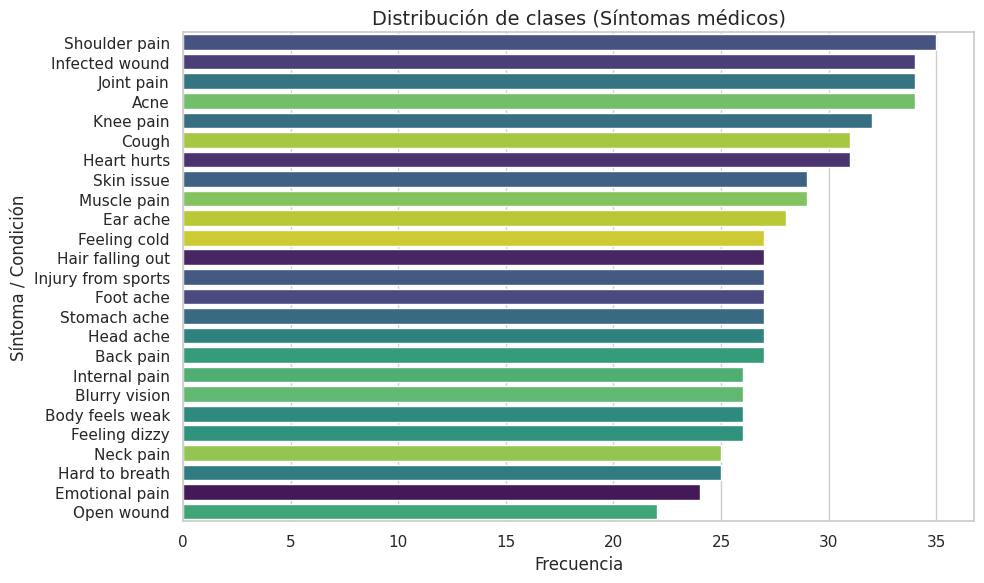


Distribución numérica de clases
                    Frecuencia  Porcentaje (%)
prompt                                        
Shoulder pain               35            4.96
Infected wound              34            4.82
Joint pain                  34            4.82
Acne                        34            4.82
Knee pain                   32            4.53
Cough                       31            4.39
Heart hurts                 31            4.39
Skin issue                  29            4.11
Muscle pain                 29            4.11
Ear ache                    28            3.97
Feeling cold                27            3.82
Hair falling out            27            3.82
Injury from sports          27            3.82
Foot ache                   27            3.82
Stomach ache                27            3.82
Head ache                   27            3.82
Back pain                   27            3.82
Internal pain               26            3.68
Blurry vision              

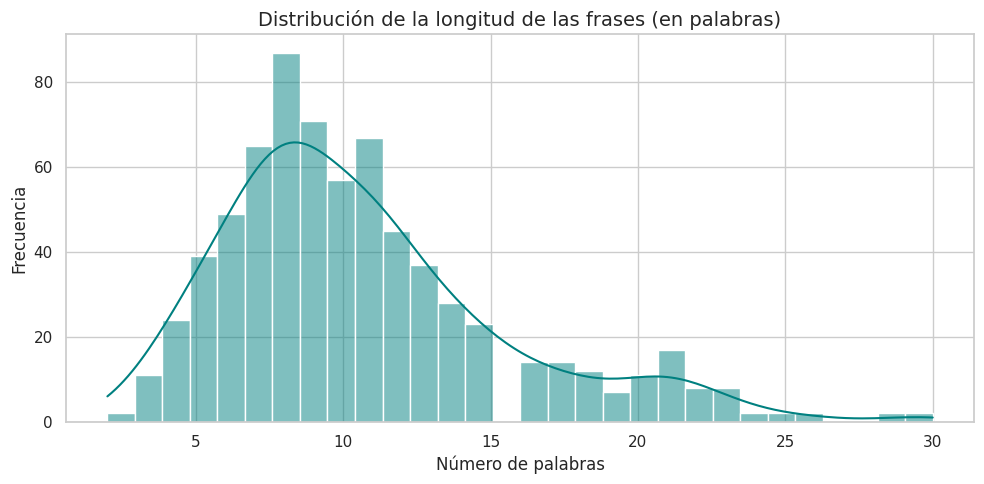


Estadísticas descriptivas de la longitud de los textos:
count    706.000000
mean      10.613314
std        4.866069
min        2.000000
25%        7.000000
50%       10.000000
75%       13.000000
max       30.000000
Name: phrase_word_count, dtype: float64

⚠️ ADVERTENCIA: 2 frases tienen menos de 3 palabras.
Ejemplos:
               phrase          prompt
13          Don't cry      Joint pain
135  i'm disappointed  Emotional pain

Verificación de duplicados exactos
✓ No hay frases duplicadas exactas en el dataset original.


In [ ]:
# Configuración de estilo
sns.set_theme(style="whitegrid")

# Distribución de clases (Síntomas / Condiciones)
# Gráfico de barras horizontal
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    y='prompt',
    hue='prompt',
    order=df['prompt'].value_counts().index,
    palette='viridis',
    legend=False
    )
plt.title('Distribución de clases (Síntomas médicos)', fontsize=14)
plt.xlabel('Frecuencia')
plt.ylabel('Síntoma / Condición')
plt.tight_layout()
plt.show()

# Tabla numérica con porcentajes
print("\n" + "="*60)
print("Distribución numérica de clases")
print("="*60)
clase_counts = df['prompt'].value_counts()
clase_percent = df['prompt'].value_counts(normalize=True) * 100
distribucion_df = pd.DataFrame({
    'Frecuencia': clase_counts,
    'Porcentaje (%)': clase_percent.round(2)
})
print(distribucion_df)
print(f"\nTotal de muestras: {len(df)}")
print(f"Número de clases únicas: {df['prompt'].nunique()}")

# Detectar clases minoritarias (menos de 30 ejemplos)
clases_minoritarias = clase_counts[clase_counts < 30]
if len(clases_minoritarias) > 0:
    print("\n⚠️ ATENCIÓN: Clases con menos de 30 muestras (pueden afectar la validación cruzada):")
    print(clases_minoritarias)
else:
    print("\n✓ Todas las clases tienen al menos 30 muestras.")

# Análisis de longitud de los textos (frases originales)
df['phrase_word_count'] = df['phrase'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['phrase_word_count'], bins=30, kde=True, color='teal')
plt.title('Distribución de la longitud de las frases (en palabras)', fontsize=14)
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Estadísticas descriptivas de la longitud de las frases
print("\n" + "="*60)
print("Estadísticas descriptivas de la longitud de los textos:")
print("="*60)
print(df['phrase_word_count'].describe())

# Detectar frases extremadamente cortas (menos de 3 palabras)
frases_cortas = df[df['phrase_word_count'] < 3]
if len(frases_cortas) > 0:
    print(f"\n⚠️ ADVERTENCIA: {len(frases_cortas)} frases tienen menos de 3 palabras.")
    print("Ejemplos:")
    print(frases_cortas[['phrase', 'prompt']].head(5))
else:
    print("\n✓ No hay frases con menos de 3 palabras.")


# Verificación de duplicados exactos (crítico para data leakage)
print("\n" + "="*60)
print("Verificación de duplicados exactos")
print("="*60)

duplicados_phrase = df.duplicated(subset=['phrase']).sum()
if duplicados_phrase > 0:
    print(f"⚠️ Se encontraron {duplicados_phrase} filas duplicadas en la columna 'phrase'.")
    # Mostrar ejemplos de frases duplicadas
    frases_dup = df[df.duplicated(subset=['phrase'], keep=False)].sort_values('phrase')
    print("\nEjemplos de frases duplicadas (primeras 5):")
    print(frases_dup[['phrase', 'prompt']].head(5))
else:
    print("✓ No hay frases duplicadas exactas en el dataset original.")

## **2. Preprocesamiento y normalización de textos**


In [ ]:
def preprocess_text(text):
    """
    Normaliza y preprocesa el texto
    """
    # Conversión a minúsculas y eliminación de caracteres no alfabéticos
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)

    # Procesamiento con spaCy
    doc = nlp(text)

    # Filtrado de stopwords y lematización
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.text.strip() != '']

    return " ".join(tokens)

# Aplicación del preprocesamiento a la columna 'phrase'
df['clean_phrase'] = df['phrase'].apply(preprocess_text)

# Verificación de textos vacíos
vacios = df[df['clean_phrase'].str.strip() == ''].shape[0]
if vacios > 0:
    print(f"⚠️ Atención: {vacios} frases quedaron vacías después del preprocesamiento.")
    # Opcional: asignar un token especial o eliminar esas filas
    df = df[df['clean_phrase'].str.strip() != ''].reset_index(drop=True)
else:
    print("✓ No hay frases vacías.")

# Normalización de la columna 'prompt' (etiquetas)
# Convertimos a minúsculas y eliminamos espacios al inicio/final
df['prompt_normalized'] = df['prompt'].astype(str).str.lower().str.strip()

# Verificación de la normalización de clases
print(f"Número de clases únicas originales: {df['prompt'].nunique()}")
print(f"Número de clases únicas normalizadas: {df['prompt_normalized'].nunique()}")

# Visualización de los cambios realizados
print("\nMuestra de textos antes y después del preprocesamiento:")
display(df[['phrase', 'clean_phrase', 'prompt', 'prompt_normalized']].head(20))

✓ No hay frases vacías.
Número de clases únicas originales: 25
Número de clases únicas normalizadas: 25

Muestra de textos antes y después del preprocesamiento:


,phrase,clean_phrase,prompt,prompt_normalized
0,When I remember her I feel down,remember feel,Emotional pain,emotional pain
1,When I carry heavy things I feel like breaking...,carry heavy thing feel like break,Hair falling out,hair falling out
2,there is too much pain when i move my arm,pain arm,Heart hurts,heart hurts
3,My son had his lip pierced and it is swollen a...,son lip pierce swollen skin inside lip grey lo...,Infected wound,infected wound
4,My muscles in my lower back are aching,muscle low ache,Infected wound,infected wound
5,i have muscle pain that my back\nI Have Muscle...,muscle pain muscle pain leg,Foot ache,foot ache
6,I have muscle pain in my left leg,muscle pain left leg,Shoulder pain,shoulder pain
7,I have cut my finger because of playing footba...,cut finger play football apply pain relief cre...,Injury from sports,injury from sports
8,I have acne in my face and other problems in m...,acne face problem derma like itching,Skin issue,skin issue
9,I have a strange rash on my arm,strange rash arm,Foot ache,foot ache



## **3. Representaciones vectoriales**




In [ ]:
# Codificación de las etiquetas (target)
le = LabelEncoder()
y = le.fit_transform(df['prompt_normalized'])

# Guardamos un mapeo de las clases para referencia futura
clases_mapping = dict(zip(le.transform(le.classes_), le.classes_))

# Generación de embeddings contextuales
print("Cargando modelo de embeddings pre-entrenado...")
# all-MiniLM-L6-v2 mapea oraciones a un espacio vectorial de 384 dimensiones
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Generando representaciones vectoriales...")
# Generamos los embeddings pasando nuestra lista de frases limpias
X = embedding_model.encode(df['clean_phrase'].tolist(), show_progress_bar=True)

# Verificación de las dimensiones resultantes
print(f"\nDimensión de la matriz de características (X): {X.shape}")
print(f"Dimensión del vector de etiquetas (y): {y.shape}")
print(f"Total de clases codificadas: {len(np.unique(y))}")

Cargando modelo de embeddings pre-entrenado...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generando representaciones vectoriales...


Batches:   0%|          | 0/23 [00:00<?, ?it/s]


Dimensión de la matriz de características (X): (706, 384)
Dimensión del vector de etiquetas (y): (706,)
Total de clases codificadas: 25


## **Preparación de datos y configuración de modelos**

In [ ]:
# División del dataset (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Configuración de la validación cruzada estratificada de 10 folds
cv_stratificada = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Definición de modelos y sus hiperparámetros para GridSearch
modelos_parametros = {
    'Regresion_Logistica': {
        'modelo': LogisticRegression(max_iter=1000, random_state=42),
        'parametros': {
            'C': [0.1, 1, 10]
        }
    },
    'SVM': {
        'modelo': SVC(random_state=42),
        'parametros': {
            'C': [1, 10],
            'kernel': ['linear', 'rbf']
        }
    },
    'Random_Forest': {
        'modelo': RandomForestClassifier(random_state=42),
        'parametros': {
            'n_estimators': [50, 100],
            'max_depth': [None, 10]
        }
    }
}

## **4. Preparación de datos y configuración de modelos**

In [ ]:
# Entrenamiento y optimización
resultados = []
mejor_modelo_global = None
mejor_score_global = 0
nombre_mejor_modelo = ""

print("Iniciando entrenamiento y optimización de modelos...\n")
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} características")
print(f"Validación cruzada: 10 folds estratificados\n")

for nombre, config in modelos_parametros.items():
    inicio_tiempo = time.time()
    print(f"Entrenando {nombre}...")

    # Configuración de GridSearchCV
    grid_search = GridSearchCV(
        estimator=config['modelo'],
        param_grid=config['parametros'],
        cv=cv_stratificada,
        scoring='f1_weighted',
        n_jobs=-1
    )

    # Ajuste del modelo
    grid_search.fit(X_train, y_train)

    tiempo_transcurrido = time.time() - inicio_tiempo

    # Almacenamiento de resultados
    mejor_score = grid_search.best_score_
    resultados.append({
        'Modelo': nombre,
        'Mejores parámetros': grid_search.best_params_,
        'Mejor F1_weighted (CV)': mejor_score,
        'Tiempo (s)': round(tiempo_transcurrido, 2)
    })

    print(f"Terminado en {tiempo_transcurrido:.2f}s. Mejor F1_weighted (CV): {mejor_score:.4f}\n")

    # Selección del mejor modelo global
    if mejor_score > mejor_score_global:
        mejor_score_global = mejor_score
        mejor_modelo_global = grid_search.best_estimator_
        nombre_mejor_modelo = nombre

# Resumen visual de los resultados de entrenamiento
df_resultados = pd.DataFrame(resultados)
print("=== Resumen de validación cruzada (Train) ===")
display(df_resultados)

Iniciando entrenamiento y optimización de modelos...

Conjunto de entrenamiento: 564 muestras, 384 características
Validación cruzada: 10 folds estratificados

Entrenando Regresion_Logistica...
Terminado en 3.41s. Mejor F1_weighted (CV): 0.7882

Entrenando SVM...
Terminado en 4.47s. Mejor F1_weighted (CV): 0.7999

Entrenando Random_Forest...
Terminado en 39.72s. Mejor F1_weighted (CV): 0.7453

=== Resumen de validación cruzada (Train) ===


,Modelo,Mejores parámetros,Mejor F1_weighted (CV),Tiempo (s)
0,Regresion_Logistica,{'C': 1},0.788247,3.41
1,SVM,"{'C': 1, 'kernel': 'rbf'}",0.799917,4.47
2,Random_Forest,"{'max_depth': None, 'n_estimators': 100}",0.745348,39.72


## **5. Evaluación del mejor modelo**


=== Evaluando el mejor modelo global (SVM) en test ===
Accuracy en test: 0.7746
F1-score (weighted) en test: 0.7657
F1-score (macro) en test: 0.7647

=== Reporte de clasificación detallado ===
                    precision    recall  f1-score   support

              acne       1.00      1.00      1.00         7
         back pain       0.40      0.40      0.40         5
     blurry vision       1.00      0.80      0.89         5
   body feels weak       0.57      0.80      0.67         5
             cough       0.86      1.00      0.92         6
          ear ache       1.00      1.00      1.00         6
    emotional pain       1.00      0.60      0.75         5
      feeling cold       0.86      1.00      0.92         6
     feeling dizzy       1.00      0.60      0.75         5
         foot ache       0.67      0.40      0.50         5
  hair falling out       0.83      1.00      0.91         5
    hard to breath       0.80      0.80      0.80         5
         head ache       

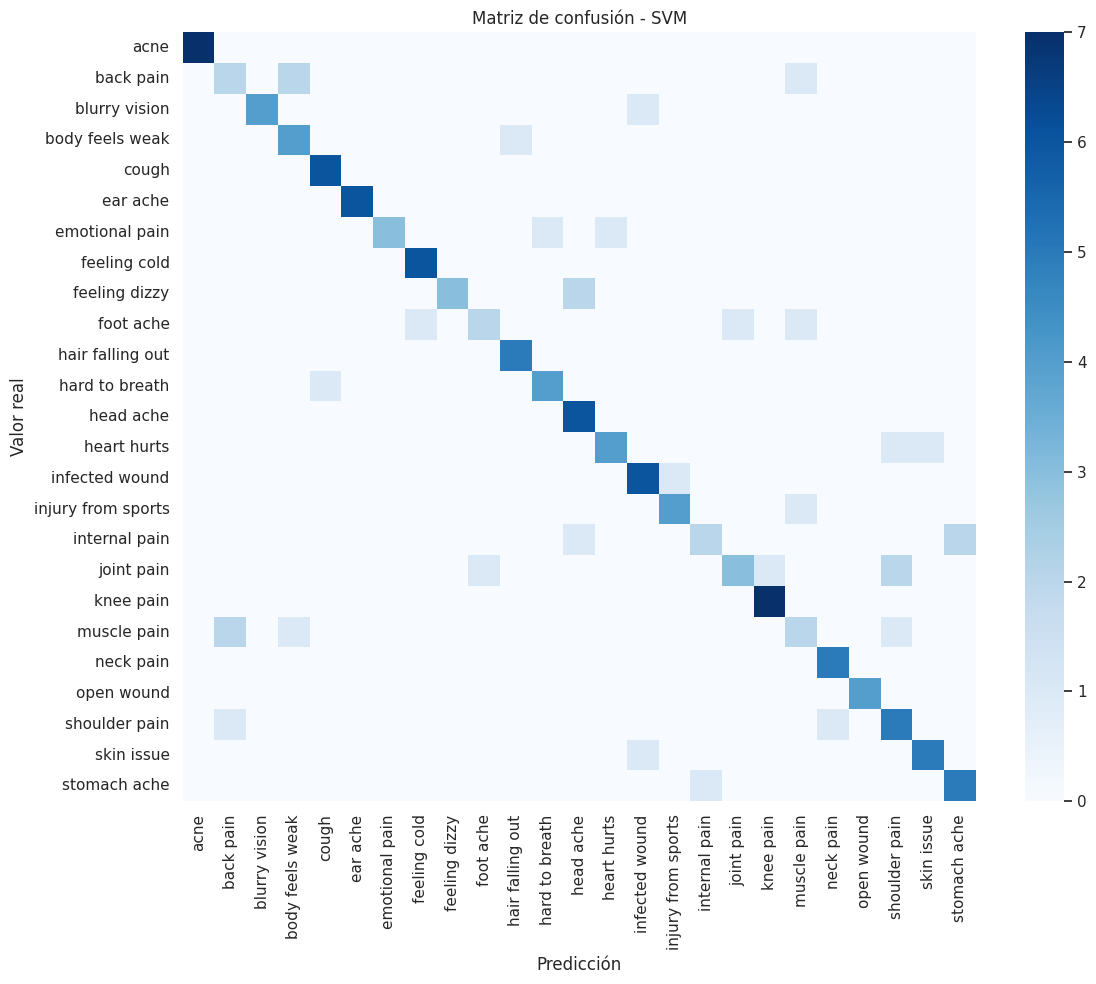


Clase con peor F1-score: 'muscle pain' con 0.36


In [ ]:
# Evaluación del mejor modelo en el conjunto de prueba (Test)
print(f"\n=== Evaluando el mejor modelo global ({nombre_mejor_modelo}) en test ===")

# Predicciones
y_pred = mejor_modelo_global.predict(X_test)

# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy en test: {accuracy:.4f}")
print(f"F1-score (weighted) en test: {f1_weighted:.4f}")
print(f"F1-score (macro) en test: {f1_macro:.4f}\n")

# Mapeo inverso de las etiquetas para el reporte
nombres_clases = [clases_mapping[i] for i in range(len(clases_mapping))]

# Generación del reporte de clasificación
reporte = classification_report(y_test, y_pred, target_names=nombres_clases)
print("=== Reporte de clasificación detallado ===")
print(reporte)

# Matriz de confusión visual
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=False,
    cmap='Blues',
    cbar=True,
    xticklabels=nombres_clases,
    yticklabels=nombres_clases
    )
plt.title(f'Matriz de confusión - {nombre_mejor_modelo}')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Clases con peor rendimiento
report_dict = classification_report(y_test, y_pred, target_names=nombres_clases, output_dict=True)
peor_f1 = min([(cls, report_dict[cls]['f1-score']) for cls in nombres_clases if cls != 'accuracy'], key=lambda x: x[1])
print(f"\nClase con peor F1-score: '{peor_f1[0]}' con {peor_f1[1]:.2f}")